# Nelkit Chavez — Individual Model Notebook
**Branch:** `student/<name>-model`

This notebook contains two architectures as required by AT3:
- **Model 1** (Phase 2): Individual architecture
- **Model 2** (Phase 3): Refined architecture based on group discussion

> **Prerequisites:** The shared `data_preparation.ipynb` must have been run at least once  
> and its outputs uploaded to the shared Google Drive folder before running this notebook.

In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Install dependencies

In [48]:
!pip install -q torch torchvision nltk Pillow matplotlib rouge-score

## 1. Mount Google Drive & load processed data

In [49]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── Shared Drive paths (must match data_preparation.ipynb) ───────────────────
DRIVE_FOLDER    = Path('/content/drive/MyDrive/AT3-DL-ImageCaptioning')
DRIVE_PROCESSED = DRIVE_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'
DRIVE_CHECKPTS  = DRIVE_FOLDER / 'checkpoints'

STUDENT_NAME = 'student_name'  # <-- CHANGE THIS
MY_CHECKPTS  = DRIVE_CHECKPTS / STUDENT_NAME
MY_CHECKPTS.mkdir(parents=True, exist_ok=True)

# Verify Drive artefacts exist
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'OK' if p.exists() else 'MISSING — run data_preparation.ipynb first'
    print(f'[{status}] {p.name}')

n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'[OK] images_224/ — {n_imgs:,} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] vocab.pkl
[OK] splits.json
[OK] captions_clean.json
[OK] images_224/ — 7,750 images


In [50]:
import pickle, json, random
import numpy as np

with open(DRIVE_PROCESSED / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
PAD_IDX    = vocab['PAD_IDX']
SOS_IDX    = vocab['SOS_IDX']
EOS_IDX    = vocab['EOS_IDX']
UNK_IDX    = vocab['UNK_IDX']
VOCAB_SIZE = len(word2idx)

with open(DRIVE_PROCESSED / 'splits.json') as f:
    splits = json.load(f)

with open(DRIVE_PROCESSED / 'captions_clean.json') as f:
    clean_data = json.load(f)

captions_clean = clean_data['captions']
id_to_filename = clean_data['id_to_filename']

print(f'Vocab size   : {VOCAB_SIZE:,}')
print(f'Train images : {len(splits["train"]):,}  Val: {len(splits["val"]):,}  Test: {len(splits["test"]):,}')

Vocab size   : 3,965
Train images : 6,181  Val: 772  Test: 774


## 2. Imports & device setup

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Shared loss — used by both Model 1 and Model 2
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

Device: cuda


## 3. Dataset & DataLoader

In [52]:
class VizWizDataset(Dataset):
    """Loads images from Drive and tokenised captions from memory."""

    DEFAULT_TRANSFORM = T.Compose([
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # 1×1 black fallback returned when a file is corrupt/missing
    _FALLBACK = T.ToTensor()(Image.new('RGB', (224, 224), (0, 0, 0)))

    def __init__(self, image_ids, captions, id_to_filename, img_dir, word2idx, transform=None):
        self.samples = []
        for img_id in image_ids:
            img_id_str = str(img_id)
            fname = id_to_filename.get(img_id_str)
            if fname is None:
                continue
            for tokens in captions.get(img_id_str, []):
                indices = ([SOS_IDX]
                           + [word2idx.get(t, UNK_IDX) for t in tokens]
                           + [EOS_IDX])
                self.samples.append((img_dir / fname, indices))

        self.transform = transform or self.DEFAULT_TRANSFORM

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, caption_indices = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            img_tensor = self.transform(img)
        except Exception:
            # Corrupt or missing file — return a black image so the batch doesn't crash.
            # The caption is still valid; the model sees a blank image for this sample.
            img_tensor = self.transform(Image.new('RGB', (256, 256), (0, 0, 0)))
        return img_tensor, torch.tensor(caption_indices, dtype=torch.long)


def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)
    lengths = [len(c) for c in captions]
    padded = torch.zeros(len(captions), max(lengths), dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, torch.tensor(lengths)

print('VizWizDataset and collate_fn defined.')

VizWizDataset and collate_fn defined.


In [53]:
BATCH_SIZE = 32

TRAIN_TRANSFORM = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = VizWizDataset(splits['train'], captions_clean, id_to_filename, DRIVE_IMAGES, word2idx, transform=TRAIN_TRANSFORM)
val_dataset   = VizWizDataset(splits['val'],   captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
test_dataset  = VizWizDataset(splits['test'],  captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)

# persistent_workers=True keeps worker processes alive between epochs so the
# destructor that triggers the Python 3.12 AssertionError is never called
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True, persistent_workers=True)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 938  Val: 118  Test: 118


---
# Model 1 — Phase 2: CNN Encoder + LSTM Decoder

## Architecture overview

Image captioning is a **sequence-to-sequence problem** where the input is an image
and the output is a variable-length sentence. The classic solution (Show and Tell, Vinyals et al. 2015)
splits the problem into two cooperating modules:

```
Image → [Encoder CNN] → feature vector → [Decoder LSTM] → word₁, word₂, ..., <EOS>
```

### Encoder: MobileNetV3-Small (partially unfrozen)
MobileNetV3-Small pretrained on ImageNet serves as the visual backbone. Its `features` layers extract
progressively abstract visual patterns; its `avgpool` collapses the spatial grid
into a single 576-dimensional vector. **The first 9 of 13 feature blocks are frozen**
(low-level detectors that transfer well from ImageNet) and **the last 4 are left trainable**
(high-level semantics that benefit from adapting to VizWiz's noisy, real-world images).
A linear projection maps the 576-dim vector to `EMBED_SIZE=256`.

### Decoder: 1-layer LSTM
The projected image feature initialises the LSTM hidden and cell states. At each
time step the LSTM receives the embedding of the previous word and produces a
distribution over the vocabulary. During **training**, teacher forcing is applied
(feeding the ground-truth previous word). During **inference**, **beam search
with k=3** finds a high-probability caption without greedily committing to the
single best word at each step.

### Hyperparameters chosen
| Hyperparameter | Value | Reason |
|---|---|---|
| Embed size | 256 | Matches encoder projection; keeps decoder small |
| Hidden size | 512 | Enough capacity without exceeding Colab RAM |
| LSTM layers | 1 | Standard for captioning baselines |
| Beam width | 3 | Good BLEU/speed trade-off |
| Freeze boundary | features[0:9] frozen | Preserves low-level ImageNet features |

## 3.1 Additional imports for Model 1

A few utilities are needed beyond the boilerplate loaded above:
- `heapq` — min-heap used inside beam search (stdlib, no install needed)
- `nltk.translate.bleu_score` — corpus-level BLEU metric
- `tqdm` — progress bars during training loops

In [54]:
import heapq
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm
from rouge_score import rouge_scorer

## 4. Encoder — MobileNetV3-Small

MobileNetV3-Small is made of three named sub-modules:
- `features` — 13 sequential blocks of inverted residuals + squeeze-and-excitation; outputs `(B, 576, 7, 7)`
- `avgpool` — adaptive average pool → `(B, 576, 1, 1)`
- `classifier` — two Linear layers for ImageNet classes (discarded here)

**Freeze strategy:** blocks `features[0]` through `features[8]` detect edges, textures, and basic
shapes that transfer directly from ImageNet — freezing them speeds up training and avoids
overwriting stable representations. Blocks `features[9]` through `features[12]` detect higher-level
patterns (object parts, scenes) that benefit from fine-tuning on VizWiz's noisy photography.

**Projection:** a single `Linear(576 → embed_size)` + `BatchNorm1d` + `ReLU` maps the pooled
feature to the same dimensionality that the decoder embedding layer uses, so the LSTM
receives a consistently-scaled initial state.

In [ ]:
class EncoderCNN(nn.Module):
    """
    Wraps MobileNetV3-Small as a visual feature extractor.

    Forward pass:
        images  : (B, 3, 224, 224)  — normalised ImageNet tensors
        returns : (B, embed_size)   — projected feature vectors
    """

    _MOBILENET_OUT_DIM = 576  # channels after MobileNetV3-Small avgpool

    def __init__(self, embed_size: int, freeze_until: int = 9):
        """
        Args:
            embed_size   : output dim — must match DecoderLSTM's embed_size
            freeze_until : freeze features[0 : freeze_until], unfreeze the rest.
                           MobileNetV3-Small has 13 blocks (indices 0-12).
                           Default=9 keeps low-level ImageNet detectors frozen.
        """
        super().__init__()

        backbone = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        self.features = backbone.features  # (B,3,224,224) → (B,576,7,7)
        self.avgpool  = backbone.avgpool   # (B,576,7,7)   → (B,576,1,1)

        # Freeze early blocks (edges, textures — stable ImageNet features)
        # Unfreeze late blocks (object parts, scenes — adapt to VizWiz)
        for i, block in enumerate(self.features):
            for p in block.parameters():
                p.requires_grad = (i >= freeze_until)

        # Project 576-dim pooled vector to embed_size
        self.projection = nn.Sequential(
            nn.Linear(self._MOBILENET_OUT_DIM, embed_size),
            nn.BatchNorm1d(embed_size),
            nn.ReLU(),
        )

    def forward(self, images):
        x = self.features(images)  # (B, 576, 7, 7)
        x = self.avgpool(x)        # (B, 576, 1, 1)
        x = x.flatten(1)           # (B, 576)
        x = self.projection(x)     # (B, embed_size)
        return x


# Quick sanity check — verifies shapes without running a full forward pass
_enc_test = EncoderCNN(embed_size=256)
_frozen   = sum(p.numel() for p in _enc_test.parameters() if not p.requires_grad)
_trainable= sum(p.numel() for p in _enc_test.parameters() if p.requires_grad)
print(f'EncoderCNN  frozen params : {_frozen:,}')
print(f'EncoderCNN trainable params: {_trainable:,}')
del _enc_test

In [ ]:
# ── Freeze map: which MobileNetV3-Small blocks are trainable ─────────────────
_enc = EncoderCNN(embed_size=256)

print(f'  {"Block":<20} {"Trainable":<12} {"Params":>10}')
print('  ' + '-' * 46)

for name, module in [*[(f'features[{i}]', b) for i, b in enumerate(_enc.features)],
                      ('projection',      _enc.projection)]:
    params     = list(module.parameters())
    n_params   = sum(p.numel() for p in params)
    trainable  = any(p.requires_grad for p in params)
    status     = '✓ ON ' if trainable else '✗ OFF'
    bar        = '█' * 20 if trainable else '░' * 20
    print(f'  {name:<20} {status}  {bar}  {n_params:>8,}')

total_frozen    = sum(p.numel() for p in _enc.parameters() if not p.requires_grad)
total_trainable = sum(p.numel() for p in _enc.parameters() if p.requires_grad)
print('  ' + '-' * 46)
print(f'  {"Frozen":<20} {total_frozen:>34,}')
print(f'  {"Trainable":<20} {total_trainable:>34,}')

del _enc


## 5. Decoder — LSTM with Beam Search

### How the LSTM decoder works

The decoder operates like a reader who has seen the image once and is now writing a caption word by word, always looking back at what was written last.

**Initialisation:** the encoder output (shape `(B, embed_size)`) seeds *both* the LSTM hidden state `h₀` and cell state `c₀` through two separate linear layers. This is the standard Show-and-Tell wiring.

**Teacher forcing (training):** the ground-truth caption is fed in, shifted right by one position.  
At step `t` the LSTM sees `[embed(word_{t-1})]` and predicts `word_t`.  
This keeps training stable — the decoder always has a correct previous word, so errors don't compound.

**Beam search (inference):** instead of always picking the single best word, beam search keeps the `k=3` most probable *sequences* alive at each step, expands all of them, and retains only the top-k. At the end it returns the sequence with the highest total log-probability. This consistently produces higher BLEU scores than greedy decoding.

### Beam search internals

The heap stores tuples `(-log_prob, sequence, (h, c))` — negative because Python's `heapq` is a min-heap and the highest log-probability should sit at the top. Each step:
1. Pop the best incomplete sequence.
2. Feed its last token into the LSTM → get next-word logits.
3. Take the top-k words, push k new candidates back onto the heap.
4. Stop when `<EOS>` is generated or `max_len` is reached.

In [ ]:
class DecoderLSTM(nn.Module):
    """
    One-layer LSTM caption generator.

    Training  : forward(features, captions)  — teacher-forcing, returns logits
    Inference : generate(features)           — beam search, returns token list
    """

    def __init__(self, embed_size: int, hidden_size: int, vocab_size: int,
                 num_layers: int = 1, dropout: float = 0.5):
        super().__init__()

        self.hidden_size = hidden_size

        # Word embedding table: maps each token index to a dense vector
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)

        # LSTM core
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Two linear layers to map the encoder feature → LSTM initial states
        # We need separate projections because h and c play different roles in an LSTM
        self.init_h = nn.Linear(embed_size, hidden_size)
        self.init_c = nn.Linear(embed_size, hidden_size)

        # Dropout applied to LSTM output before projection (regularisation)
        self.dropout = nn.Dropout(dropout)

        # Project hidden state to vocabulary logits
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def _init_hidden(self, features):
        """Seed LSTM states from the encoder feature vector."""
        # features: (B, embed_size)
        # LSTM expects (num_layers, B, hidden_size)
        h = self.init_h(features).unsqueeze(0)  # (1, B, hidden_size)
        c = self.init_c(features).unsqueeze(0)  # (1, B, hidden_size)
        return h, c

    def forward(self, features, captions):
        """
        Teacher-forcing forward pass used during training.

        Args:
            features : (B, embed_size)     — encoder output
            captions : (B, seq_len)        — token indices including <SOS> and <EOS>

        Returns:
            logits   : (B, seq_len-1, vocab_size)
                       Predictions for positions 1..seq_len (i.e. every word after <SOS>)
        """
        h, c = self._init_hidden(features)

        # Drop <EOS> from the input; the decoder never needs to predict what comes after EOS
        # captions[:, :-1] = [<SOS>, w1, w2, ..., w_{n-1}]
        # target (computed in training loop) = captions[:, 1:] = [w1, w2, ..., <EOS>]
        embeddings = self.embedding(captions[:, :-1])   # (B, seq_len-1, embed_size)

        out, _ = self.lstm(embeddings, (h, c))           # (B, seq_len-1, hidden_size)
        out    = self.dropout(out)
        logits = self.fc_out(out)                        # (B, seq_len-1, vocab_size)
        return logits

    @torch.no_grad()
    def generate(self, features, max_len: int = 30, beam_width: int = 3):
        """
        Beam search inference for a SINGLE image feature vector.

        Args:
            features   : (1, embed_size) — encoder output for one image
            max_len    : maximum caption length (tokens, not counting <SOS>)
            beam_width : number of candidate sequences to keep alive at each step

        Returns:
            List[int] — best token sequence (excludes <SOS>, includes <EOS> if reached)
        """
        h, c = self._init_hidden(features)  # (1, 1, hidden_size) each

        # Heap entries: (-cumulative_log_prob, token_sequence, (h, c))
        # Negative log-prob because heapq is a min-heap → lowest neg = highest prob
        initial_token = torch.tensor([[SOS_IDX]], device=features.device)
        init_emb      = self.embedding(initial_token)            # (1,1,embed_size)
        out, (h, c)   = self.lstm(init_emb, (h, c))
        log_probs     = torch.log_softmax(self.fc_out(out[:, -1, :]), dim=-1)  # (1, vocab)

        # Seed the heap with the top-beam_width tokens after <SOS>
        top_probs, top_ids = log_probs[0].topk(beam_width)
        heap = []
        for prob, tok in zip(top_probs.tolist(), top_ids.tolist()):
            heapq.heappush(heap, (-prob, [tok], (h.clone(), c.clone())))

        completed = []

        for _ in range(max_len - 1):
            if not heap:
                break

            candidates = []
            # Expand every beam candidate exactly once per step
            for _ in range(len(heap)):
                neg_prob, seq, (h_beam, c_beam) = heapq.heappop(heap)

                if seq[-1] == EOS_IDX:
                    completed.append((neg_prob, seq))
                    continue

                last_tok = torch.tensor([[seq[-1]]], device=features.device)
                emb      = self.embedding(last_tok)               # (1,1,embed_size)
                out, (h_new, c_new) = self.lstm(emb, (h_beam, c_beam))
                lp       = torch.log_softmax(self.fc_out(out[:, -1, :]), dim=-1)

                top_probs, top_ids = lp[0].topk(beam_width)
                for prob, tok in zip(top_probs.tolist(), top_ids.tolist()):
                    new_neg_prob = neg_prob - prob   # accumulate (subtract because neg)
                    candidates.append((new_neg_prob, seq + [tok], (h_new.clone(), c_new.clone())))

            # Keep only the beam_width best candidates
            candidates.sort(key=lambda x: x[0])
            heap = []
            for entry in candidates[:beam_width]:
                heapq.heappush(heap, entry)

        # Drain remaining live beams into completed
        while heap:
            neg_prob, seq, _ = heapq.heappop(heap)
            completed.append((neg_prob, seq))

        if not completed:
            return []

        # Return the sequence with the lowest negative log-prob (= highest probability)
        best = min(completed, key=lambda x: x[0])
        tokens = best[1]
        # Strip trailing <EOS> if present (cleaner for display and BLEU)
        if tokens and tokens[-1] == EOS_IDX:
            tokens = tokens[:-1]
        return tokens


# Sanity check — parameter count
_dec_test = DecoderLSTM(embed_size=256, hidden_size=512, vocab_size=3965)
_dec_params = sum(p.numel() for p in _dec_test.parameters())
print(f'DecoderLSTM total params: {_dec_params:,}')
del _dec_test

## 6. Hyperparameters & model instantiation

All values are documented inline. Change them here — the training loop reads from these variables.

**Why these specific values:**
- `EMBED_SIZE=256` — small enough that the full model fits in Colab RAM, large enough to express semantic similarity between words
- `HIDDEN_SIZE=512` — standard for single-layer LSTM captioners; doubles the embed to give the recurrent state more room
- `LR=3e-4` — Adam's sweet spot for mixed encoder+decoder training; lower LR for the encoder is handled via separate param groups
- `CLIP=5.0` — gradient clipping prevents exploding gradients, which are common in LSTMs on early epochs
- `ENCODER_LR_SCALE=0.1` — the unfrozen encoder blocks are already well-trained, so they need a much smaller update than the randomly-initialised decoder

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_SIZE       = 256
HIDDEN_SIZE      = 512
NUM_LAYERS       = 1
DROPOUT          = 0.5
EPOCHS           = 10
LR               = 3e-4
ENCODER_LR_SCALE = 0.1   # unfrozen encoder blocks train at LR * this factor
CLIP             = 5.0   # max gradient norm
BEAM_WIDTH       = 3

# ── Model instantiation ───────────────────────────────────────────────────────
encoder1 = EncoderCNN(embed_size=EMBED_SIZE).to(DEVICE)
decoder1 = DecoderLSTM(
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

# ── Separate param groups so encoder trains slower than decoder ───────────────
# The decoder is randomly initialised → needs full LR.
# The unfrozen encoder blocks are pretrained → need a gentler nudge.
encoder_params = [p for p in encoder1.parameters() if p.requires_grad]
decoder_params = list(decoder1.parameters())

optimizer1 = optim.Adam([
    {'params': encoder_params, 'lr': LR * ENCODER_LR_SCALE},
    {'params': decoder_params, 'lr': LR},
])

# Reduce LR by half when val loss stops improving for 2 epochs
# verbose was removed in PyTorch 2.x — LR changes are printed manually in the loop
scheduler1 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer1, mode='min', factor=0.5, patience=2
)


total_params = (sum(p.numel() for p in encoder1.parameters() if p.requires_grad)
                + sum(p.numel() for p in decoder1.parameters()))
print(f'Total trainable params: {total_params:,}')
print(f'Encoder trainable     : {sum(p.numel() for p in encoder_params):,}')
print(f'Decoder trainable     : {sum(p.numel() for p in decoder_params):,}')

## 7. Training loop

Each epoch does two passes:
1. **Train pass** — forward → loss → backward → clip gradients → optimizer step
2. **Val pass** — forward only (no gradients), accumulate loss

**Why `encoder1.train()` / `encoder1.eval()` matter:**
BatchNorm (inside the encoder projection) behaves differently in train vs eval mode.
In train mode it uses the batch statistics; in eval mode it uses the running statistics
accumulated during training. Getting this wrong inflates val loss.

**Why gradient clipping is applied:**
LSTMs are prone to exploding gradients, especially in early epochs when the randomly-initialised
decoder produces large errors that backprop through many time steps. Clipping at norm=5.0
keeps updates bounded without slowing down learning.

**Checkpoint strategy:**
The checkpoint with the lowest *validation loss* (not training loss) is saved — this is the best
proxy for generalisation. Both encoder and decoder state dicts are saved together so they
can be loaded as a matched pair.

In [ ]:
def run_epoch(encoder, decoder, loader, optimizer, criterion, device, train: bool):
    """Single train or val epoch. Returns mean loss over all tokens."""
    encoder.train(train)
    decoder.train(train)

    total_loss = 0.0
    total_tokens = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, captions, lengths in tqdm(loader, leave=False,
                                               desc='train' if train else 'val'):
            images   = images.to(device)
            captions = captions.to(device)

            features = encoder(images)                    # (B, embed_size)
            logits   = decoder(features, captions)        # (B, seq_len-1, vocab_size)

            # Reshape for cross-entropy: (B * seq_len-1, vocab_size) vs (B * seq_len-1,)
            # Target is captions[:, 1:] — every word from the first real word to <EOS>
            B, S, V = logits.shape
            loss = criterion(
                logits.reshape(B * S, V),
                captions[:, 1:].reshape(B * S),
            )

            if train:
                optimizer.zero_grad()
                loss.backward()
                # Clip to prevent LSTM gradient explosion
                nn.utils.clip_grad_norm_(
                    list(encoder.parameters()) + list(decoder.parameters()), CLIP
                )
                optimizer.step()

            # Count non-PAD tokens for a fair per-token loss average
            n_tokens = (captions[:, 1:] != PAD_IDX).sum().item()
            total_loss   += loss.item() * n_tokens
            total_tokens += n_tokens

    return total_loss / total_tokens


# ── Training loop ─────────────────────────────────────────────────────────────
history1  = {'train_loss': [], 'val_loss': []}
best_val  = float('inf')
CKPT_PATH = MY_CHECKPTS / 'model1_best.pth'

print(f'Training for {EPOCHS} epochs on {DEVICE} ...\n')

prev_lrs = [pg['lr'] for pg in optimizer1.param_groups]

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(encoder1, decoder1, train_loader,
                           optimizer1, criterion, DEVICE, train=True)
    val_loss   = run_epoch(encoder1, decoder1, val_loader,
                           optimizer1, criterion, DEVICE, train=False)

    scheduler1.step(val_loss)

    # Detect and report LR reduction (replaces the removed verbose= argument)
    curr_lrs = [pg['lr'] for pg in optimizer1.param_groups]
    if curr_lrs != prev_lrs:
        print(f'  LR reduced → encoder {curr_lrs[0]:.2e}  decoder {curr_lrs[1]:.2e}')
        prev_lrs = curr_lrs

    history1['train_loss'].append(train_loss)
    history1['val_loss'].append(val_loss)

    marker = ''
    if val_loss < best_val:
        best_val = val_loss
        torch.save({
            'epoch':           epoch,
            'encoder_state':   encoder1.state_dict(),
            'decoder_state':   decoder1.state_dict(),
            'optimizer_state': optimizer1.state_dict(),
            'val_loss':        val_loss,
            'hyperparams': {
                'embed_size':  EMBED_SIZE,
                'hidden_size': HIDDEN_SIZE,
                'num_layers':  NUM_LAYERS,
                'vocab_size':  VOCAB_SIZE,
                'beam_width':  BEAM_WIDTH,
            },
        }, CKPT_PATH)
        marker = '  ← best saved'

    print(f'Epoch {epoch:02d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{marker}')

print(f'\nTraining complete. Best val loss: {best_val:.4f}')
print(f'Checkpoint saved to: {CKPT_PATH}')

## 7.1 Training curve & checkpoint reload

Plot train vs val loss to diagnose overfitting or underfitting, then reload the best
checkpoint so evaluation always runs on the model that generalised best — not the
final epoch, which may have already started to overfit.

In [ ]:
# ── Loss curve ────────────────────────────────────────────────────────────────
epochs_range = range(1, len(history1['train_loss']) + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, history1['train_loss'], label='Train loss', marker='o')
ax.plot(epochs_range, history1['val_loss'],   label='Val loss',   marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss (per token)')
ax.set_title('Model 1 — Training curve')
ax.legend()
plt.tight_layout()
plt.show()

# ── Reload best checkpoint ────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
encoder1.load_state_dict(ckpt['encoder_state'])
decoder1.load_state_dict(ckpt['decoder_state'])
print(f'Loaded best checkpoint from epoch {ckpt["epoch"]}  (val_loss={ckpt["val_loss"]:.4f})')

## 8. Evaluation — BLEU-1 to BLEU-4 + ROUGE-L

**BLEU** counts n-gram overlap between the generated caption and the reference captions.
Higher n-gram order = harder to achieve, more sensitive to fluency.

**ROUGE-L** measures the length of the Longest Common Subsequence (LCS) between
hypothesis and reference. Unlike BLEU, it does not require n-grams to be contiguous —
it rewards capturing the overall narrative structure even when word order differs slightly.
It is reported as an F1 score (harmonic mean of LCS-precision and LCS-recall).

ROUGE-L complements BLEU well: a model that generates fluent but generic captions can
score well on BLEU-1 while scoring lower on ROUGE-L, exposing the difference.

**Expected ranges for this dataset and architecture:**
| Metric | Rough expectation |
|---|---|
| BLEU-1  | 0.45 – 0.60 |
| BLEU-2  | 0.25 – 0.40 |
| BLEU-3  | 0.15 – 0.28 |
| BLEU-4  | 0.08 – 0.18 |
| ROUGE-L | 0.30 – 0.50 |

These are approximate — VizWiz is harder than MSCOCO because images are blurry/occluded.

In [ ]:
def generate_captions_for_loader(encoder, decoder, loader, device,
                                  beam_width=3, max_len=30):
    """
    Run beam search over every image in a DataLoader.

    Returns
    -------
    hypotheses : List[List[str]]        — one generated caption per sample
    references : List[List[List[str]]]  — shape required by corpus_bleu
    """
    encoder.eval()
    decoder.eval()

    hypotheses = []
    references = []

    with torch.no_grad():
        for images, captions, lengths in tqdm(loader, desc='Generating captions'):
            images   = images.to(device)
            captions = captions.to(device)

            features = encoder(images)   # (B, embed_size)

            for i in range(features.size(0)):
                feat = features[i].unsqueeze(0)   # (1, embed_size)

                pred_tokens = decoder.generate(feat, max_len=max_len, beam_width=beam_width)
                pred_words  = [idx2word.get(t, '<UNK>') for t in pred_tokens]
                hypotheses.append(pred_words)

                ref_tokens = captions[i].tolist()
                ref_words  = []
                for t in ref_tokens:
                    if t in (PAD_IDX, SOS_IDX):
                        continue
                    if t == EOS_IDX:
                        break
                    ref_words.append(idx2word.get(t, '<UNK>'))
                references.append([ref_words])

    return hypotheses, references


def compute_bleu_scores(hypotheses, references):
    """BLEU-1 through BLEU-4 via corpus_bleu."""
    smoother = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1, 0, 0, 0), smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(0.5, 0.5, 0, 0), smoothing_function=smoother)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(1/3, 1/3, 1/3, 0), smoothing_function=smoother)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)
    return bleu1, bleu2, bleu3, bleu4


def compute_rouge_l(hypotheses, references):
    """
    Corpus-level ROUGE-L F1, averaged across all test samples.

    ROUGE-L rewards capturing the narrative structure of a sentence via the
    Longest Common Subsequence — contiguous n-gram matches are not required.
    corpus_bleu aggregates internally; rouge_scorer does not, so we average
    per-sample F1 scores manually (standard practice in captioning literature).
    """
    scorer   = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    total_f1 = 0.0

    for hyp_words, ref_list in zip(hypotheses, references):
        hyp_str  = ' '.join(hyp_words)
        ref_str  = ' '.join(ref_list[0])   # one reference per sample in the loader
        score    = scorer.score(ref_str, hyp_str)
        total_f1 += score['rougeL'].fmeasure

    return total_f1 / len(hypotheses) if hypotheses else 0.0


# ── Run evaluation on test split ──────────────────────────────────────────────
print('Generating captions on test split (beam_width=3) ...')
hyps1, refs1 = generate_captions_for_loader(
    encoder1, decoder1, test_loader, DEVICE, beam_width=BEAM_WIDTH
)

b1, b2, b3, b4 = compute_bleu_scores(hyps1, refs1)
rouge_l        = compute_rouge_l(hyps1, refs1)

print('\n' + '='*42)
print('  Model 1 — Evaluation (test set)')
print('='*42)
print(f'  BLEU-1  : {b1:.4f}')
print(f'  BLEU-2  : {b2:.4f}')
print(f'  BLEU-3  : {b3:.4f}')
print(f'  BLEU-4  : {b4:.4f}')
print(f'  ROUGE-L : {rouge_l:.4f}')
print('='*42)

## 9. Visual inspection — generated vs. reference captions

Numbers alone (BLEU) don't reveal whether the model is generating reasonable English or
hallucinating nonsense. Examining real predictions helps identify failure modes:
- Is the model stuck repeating the same phrase?
- Does it describe objects that aren't in the image?
- Does the language sound fluent even when the content is wrong?

The section below shows 10 random images from the test set. For each one:
- The image itself (de-normalised back to visible colours)
- **Generated:** the model's caption
- **Reference 1:** one of the 5 human captions (the one stored in the test batch)

In [ ]:
def show_predictions(encoder, decoder, dataset, device,
                     n_samples=10, beam_width=3, seed=42):
    encoder.eval()
    decoder.eval()

    _mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    _std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    rng     = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n_samples)

    # Extra vertical space per row to fit captions below each image
    fig, axes = plt.subplots(2, 5, figsize=(26, 12))

    with torch.no_grad():
        for ax, idx in zip(axes.flat, indices):
            image_tensor, caption_tensor = dataset[idx]

            # Generate caption
            feat        = encoder(image_tensor.unsqueeze(0).to(device))
            pred_tokens = decoder.generate(feat, beam_width=beam_width)
            pred_words  = [idx2word.get(t, '<UNK>') for t in pred_tokens]

            # Decode reference caption
            ref_words = []
            for t in caption_tensor.tolist():
                if t in (PAD_IDX, SOS_IDX):
                    continue
                if t == EOS_IDX:
                    break
                ref_words.append(idx2word.get(t, '<UNK>'))

            img_show = (image_tensor * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()

            ax.imshow(img_show)
            ax.axis('off')

            gen_str = ' '.join(pred_words) if pred_words else '(empty)'
            ref_str = ' '.join(ref_words)  if ref_words  else '(empty)'

            # Wrap text manually to avoid overflow
            import textwrap
            gen_wrapped = '\n'.join(textwrap.wrap(f'Gen: {gen_str}', width=38))
            ref_wrapped = '\n'.join(textwrap.wrap(f'Ref: {ref_str}', width=38))
            caption_text = f'{gen_wrapped}\n{ref_wrapped}'

            # Place text BELOW the image, outside the axes
            ax.text(
                0.5, -0.04,          # x=center, y=just below axes
                caption_text,
                transform=ax.transAxes,
                fontsize=12,
                ha='center',
                va='top',
                wrap=False,          # already wrapped manually
                color='black',
                bbox=dict(           # subtle background box for readability
                    boxstyle='round,pad=0.3',
                    facecolor='white',
                    alpha=0.8,
                    edgecolor='lightgray'
                )
            )

    plt.suptitle('Model 1 — Sample predictions vs. reference captions', fontsize=13)

    # Key fix: add bottom margin so captions don't get clipped
    plt.subplots_adjust(
        hspace=0.55,   # vertical space between rows
        wspace=0.15,   # horizontal space between columns
        bottom=0.05,
        top=0.93
    )

    plt.show()


show_predictions(encoder1, decoder1, test_dataset, DEVICE, n_samples=10, beam_width=BEAM_WIDTH)

---
# Group Discussion Summary

1. What architectures did each student try?
        
        - Amanda: ResNet50 + LSTM
        - Juan: ResNet50 + GRU
        - Nelkit: MobileNet + LSTM
        - Thom: MobileNet + GRU
        - Maris: GoogLeNet + LSTM

2. What worked? What did not, and why?
   
   ✅ What Worked
    Stronger encoders drove better results. ResNet50 (Juan, Amanda) and GoogLeNet (Maris) consistently outperformed MobileNet-based models, confirming that richer visual features directly benefit caption quality. GRU also showed a slight edge over LSTM when paired with ResNet50, likely due to fewer parameters and less overfitting risk. Models with proper checkpoint saving (Maris, epoch 12/15) also benefited from longer training.

    ❌ What Did Not Work
    MobileNet underperformed across both decoder types (Nelkit, Thom), as its efficiency-focused design lacks the representational depth needed for VizWiz's complex scenes. Amanda's model overfit early (best at epoch 3/15), suggesting issues with learning rate or insufficient regularization. Low TTR (0.0694, Juan) indicated repetitive captions across all models — a known limitation of attention-free encoder-decoder architectures.  

 3. What patterns emerged across experiments?
    - Encoder capacity > decoder type. BLEU rankings followed encoder strength (GoogLeNet > ResNet50 > MobileNet) regardless of whether GRU or LSTM was used.
    - All models hit a BLEU-4 ceiling below 0.24. Longer n-gram sequences were consistently poor, pointing to a shared structural limitation, **the absence of an attention mechanism.**
    - Val loss converged similarly (~3.10–3.15) across all architectures, suggesting the basic encoder-decoder framework itself is the bottleneck, not individual design choices.
    - GRU vs LSTM made little difference when the encoder was held constant, reinforcing that the encoder was the primary performance driver.
 4. How did the discussion inform the Model 2 design?
    Two key findings drove Model 2 decisions: encoder strength mattered most, and all models hit a ceiling without attention, shown by low BLEU-3/4 scores and repetitive captions.

    This led to two shared changes:

    - Members on MobileNet (Nelkit, Thom) switched to GoogLeNet
    - Everyone added an attention mechanism to the decoder, directly targeting the low BLEU-3/4 scores

---
# Model 2 — Phase 3: GoogLeNet Encoder + LSTM Decoder + Luong Attention

## What changed from Model 1 and why

The group discussion identified two consistent limitations across all Model 1 experiments:

1. **Encoder capacity was the primary performance driver.** MobileNetV3-Small consistently
   underperformed ResNet50 and GoogLeNet — its efficiency focus limits representational depth
   for VizWiz's complex, noisy scenes.

2. **All models hit a BLEU-4 ceiling below 0.24** due to the absence of an attention mechanism.
   Low BLEU-3/4 and low TTR (repetitive captions) pointed to a shared structural bottleneck.

**Two shared decisions emerged:**
- Switch encoder from MobileNet → **GoogLeNet (Inception v1)**
- Add **Luong attention** to the decoder so each word attends to the most relevant image region

## Architecture overview

```
Image → [GoogLeNet features (B,1024,7,7)] → reshape (B,49,1024) → project (B,49,512)
                                                         ↓
                                              [LSTM + Luong Attention]
                                                         ↓
                                              word₁, word₂, ..., <EOS>
```

### Encoder: GoogLeNet spatial grid
Unlike Model 1 (single global vector), the encoder now exposes the **7×7 spatial grid**
of 1024-dim vectors (49 patches total) from before GoogLeNet's avgpool. Each patch
is projected to 512 dims. The decoder can then attend to different patches at each
time step — directly targeting the repetition problem.

**Freeze strategy:** same philosophy as Model 1. The early inception modules (mixed3,
mixed4a–d) are frozen; the late modules (mixed4e, mixed5a, mixed5b) and the auxiliary
classifier are left trainable.

### Decoder: LSTM with Luong (General) Attention
At each decoding step t:
1. The embedding of the previous word is concatenated with the attention context from step t-1
2. The LSTM produces a new hidden state `h_t`
3. **General attention** computes scores: `score(h_t, enc_out_i) = h_t @ Wₐ @ enc_out_i`
4. Softmax over 49 scores → attention weights → weighted sum of encoder vectors = context
5. `fc_out` projects `concat(h_t, context)` to vocabulary logits

This is the **input-feeding** variant of Luong attention (Luong et al. 2015, eq. 5).

### Hyperparameter changes vs. Model 1
| Hyperparameter | Model 1 | Model 2 | Reason |
|---|---|---|---|
| Backbone | MobileNetV3-Small | GoogLeNet (Inception v1) | Richer features |
| Encoder out | (B, 576) global | (B, 49, 512) spatial grid | Enables attention |
| Embed size | 256 | 512 | Larger embed to match hidden size |
| Hidden size | 512 | 512 | Unchanged |
| Attention | None | Luong General | Target BLEU-3/4 ceiling |
| LR / epochs | 3e-4 / 10 | 3e-4 / 10 | Comparable baseline |

In [60]:
# ── 3.2 Additional imports for Model 2 ───────────────────────────────────────
import torch.nn.functional as F   # needed for attention softmax
# All other imports (heapq, tqdm, nltk, rouge) are already loaded from Model 1

print('Model 2 imports ready.')

Model 2 imports ready.


In [61]:
# ── Encoder 2: GoogLeNet spatial grid (mixed5a/5b unfrozen) ──────────────────
#
# CHANGE FROM MODEL 1: MobileNetV3-Small produced a single (B, 576) global vector.
# GoogLeNet here produces a (B, 49, 512) spatial grid so the decoder can attend
# to different image regions at each decoding step.
#
# CHANGE FROM CACHED VERSION: mixed5a and mixed5b are now trainable so the
# encoder adapts to VizWiz's domain. This requires running the encoder in the
# training loop (no cache).

class EncoderGoogLeNet(nn.Module):
    """
    GoogLeNet (Inception v1) encoder that returns a spatial grid of features.

    Forward pass:
        images  : (B, 3, 224, 224)
        returns : (B, 49, embed_size)   — 7×7 = 49 spatial patches, each projected
    """

    _GOOGLENET_OUT_DIM = 1024

    def __init__(self, embed_size: int = 512):
        super().__init__()

        backbone = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)

        self.backbone = nn.Sequential(
            backbone.conv1,
            backbone.maxpool1,
            backbone.conv2,
            backbone.conv3,
            backbone.maxpool2,
            backbone.inception3a,
            backbone.inception3b,
            backbone.maxpool3,
            backbone.inception4a,
            backbone.inception4b,
            backbone.inception4c,
            backbone.inception4d,
            backbone.inception4e,
            backbone.maxpool4,
            backbone.inception5a,   # index 14 — trainable
            backbone.inception5b,   # index 15 — trainable
        )

        # Freeze all blocks first, then unfreeze the last two (mixed5a, mixed5b)
        # Same ~70/30 philosophy as Model 1: early blocks frozen, late blocks adapt
        for p in self.backbone.parameters():
            p.requires_grad = False
        for module in list(self.backbone.children())[14:]:
            for p in module.parameters():
                p.requires_grad = True

        self.projection = nn.Sequential(
            nn.Linear(self._GOOGLENET_OUT_DIM, embed_size),
            nn.BatchNorm1d(embed_size),
            nn.ReLU(),
        )

    def forward(self, images):
        x = self.backbone(images)          # (B, 1024, 7, 7)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1)         # (B, 7, 7, 1024)
        x = x.reshape(B * H * W, C)       # (B*49, 1024)
        x = self.projection(x)            # (B*49, embed_size)
        x = x.reshape(B, H * W, -1)       # (B, 49, embed_size)
        return x


_enc2 = EncoderGoogLeNet(embed_size=512)
_frozen2    = sum(p.numel() for p in _enc2.parameters() if not p.requires_grad)
_trainable2 = sum(p.numel() for p in _enc2.parameters() if p.requires_grad)
print(f'EncoderGoogLeNet  frozen params    : {_frozen2:,}')
print(f'EncoderGoogLeNet  trainable params : {_trainable2:,}')
del _enc2

EncoderGoogLeNet  frozen params    : 2,470,080
EncoderGoogLeNet  trainable params : 3,655,648


In [62]:
# ── Decoder 2: LSTM + Luong (General) Attention ───────────────────────────────
#
# CHANGE FROM MODEL 1: the decoder no longer receives a single image vector at
# initialisation only. Instead, at EVERY step it computes a context vector by
# attending over the 49 spatial patches from the encoder.
#
# Luong "General" score function:
#   score(h_t, enc_i) = h_t @ Wₐ @ enc_i
# where Wₐ is a learned (hidden_size × embed_size) matrix.
# This is the input-feeding variant: context from step t is concatenated with
# the word embedding and fed as LSTM input at step t+1.

class LuongAttention(nn.Module):
    """
    General-score Luong attention over a fixed set of encoder vectors.

    score(h, enc_i) = h @ W_a @ enc_i   for each of the N encoder patches
    context         = sum_i( softmax(score_i) * enc_i )
    """

    def __init__(self, hidden_size: int, encoder_dim: int):
        super().__init__()
        # Wₐ maps encoder_dim → hidden_size so the dot product is valid
        self.W_a = nn.Linear(encoder_dim, hidden_size, bias=False)

    def forward(self, h, encoder_out):
        """
        Args:
            h           : (B, hidden_size)    — current decoder hidden state
            encoder_out : (B, N, encoder_dim) — N spatial patches from encoder

        Returns:
            context     : (B, encoder_dim)    — attended encoder vector
            weights     : (B, N)              — attention distribution (for inspection)
        """
        # Project encoder to hidden space: (B, N, hidden_size)
        proj = self.W_a(encoder_out)
        # Score = h · proj_i  for each patch i
        # h unsqueeze → (B, 1, hidden_size); bmm → (B, 1, N) → squeeze → (B, N)
        scores  = torch.bmm(h.unsqueeze(1), proj.permute(0, 2, 1)).squeeze(1)
        weights = torch.softmax(scores, dim=-1)                  # (B, N)
        # Weighted sum over encoder patches
        context = torch.bmm(weights.unsqueeze(1), encoder_out).squeeze(1)  # (B, encoder_dim)
        return context, weights


class DecoderLSTMAttention(nn.Module):
    """
    LSTM decoder with Luong input-feeding attention.

    Training  : forward(encoder_out, captions)  — teacher-forcing
    Inference : generate(encoder_out)            — beam search
    """

    def __init__(self, embed_size: int, hidden_size: int, vocab_size: int,
                 encoder_dim: int, num_layers: int = 1, dropout: float = 0.5):
        super().__init__()

        self.hidden_size = hidden_size
        self.encoder_dim = encoder_dim

        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)

        # CHANGE FROM MODEL 1: LSTM input = embed + context (input-feeding)
        # so input_size = embed_size + encoder_dim
        self.lstm = nn.LSTM(
            input_size=embed_size + encoder_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # Seed h₀ and c₀ from the mean of the encoder patches (same idea as Model 1)
        self.init_h = nn.Linear(encoder_dim, hidden_size)
        self.init_c = nn.Linear(encoder_dim, hidden_size)

        self.attention = LuongAttention(hidden_size, encoder_dim)

        self.dropout = nn.Dropout(dropout)

        # Project concat(h_t, context) → vocab logits
        # CHANGE FROM MODEL 1: output projection takes h + context, not h alone
        self.fc_out = nn.Linear(hidden_size + encoder_dim, vocab_size)

    def _init_hidden(self, encoder_out):
        """Seed LSTM states from the mean encoder patch (mirrors Model 1 approach)."""
        mean_enc = encoder_out.mean(dim=1)               # (B, encoder_dim)
        h = self.init_h(mean_enc).unsqueeze(0)           # (1, B, hidden_size)
        c = self.init_c(mean_enc).unsqueeze(0)
        return h, c

    def forward(self, encoder_out, captions):
        """
        Teacher-forcing forward pass.

        Args:
            encoder_out : (B, N, encoder_dim)  — spatial grid from EncoderGoogLeNet
            captions    : (B, seq_len)         — token indices with <SOS> and <EOS>

        Returns:
            logits      : (B, seq_len-1, vocab_size)
        """
        B, N, _ = encoder_out.shape
        h, c = self._init_hidden(encoder_out)

        embeddings = self.embedding(captions[:, :-1])    # (B, seq_len-1, embed_size)
        seq_len    = embeddings.size(1)

        # Initialise context as zeros; updated at each step
        context = encoder_out.mean(dim=1)                # (B, encoder_dim)

        all_logits = []
        for t in range(seq_len):
            emb_t  = embeddings[:, t, :]                 # (B, embed_size)
            # Input-feeding: concatenate word embedding with previous context
            lstm_in = torch.cat([emb_t, context], dim=-1).unsqueeze(1)  # (B,1,E+D)
            out, (h, c) = self.lstm(lstm_in, (h, c))     # out: (B,1,hidden)
            h_t    = out.squeeze(1)                      # (B, hidden_size)
            context, _ = self.attention(h_t, encoder_out)
            h_t_drop   = self.dropout(h_t)
            logit_t    = self.fc_out(torch.cat([h_t_drop, context], dim=-1))  # (B, vocab)
            all_logits.append(logit_t.unsqueeze(1))

        return torch.cat(all_logits, dim=1)              # (B, seq_len-1, vocab_size)

    @torch.no_grad()
    def generate(self, encoder_out, max_len: int = 30, beam_width: int = 3):
        """
        Beam search inference for a single image.

        Args:
            encoder_out : (1, N, encoder_dim)
            max_len     : max caption length
            beam_width  : k beams

        Returns:
            List[int] — best token sequence (no <SOS>, no <EOS>)
        """
        h, c = self._init_hidden(encoder_out)
        context = encoder_out.mean(dim=1)                # (1, encoder_dim)

        # Seed: run <SOS> through the first LSTM step
        sos = torch.tensor([[SOS_IDX]], device=encoder_out.device)
        emb = self.embedding(sos)                        # (1,1,embed_size)
        lstm_in = torch.cat([emb.squeeze(1), context], dim=-1).unsqueeze(1)
        out, (h, c) = self.lstm(lstm_in, (h, c))
        h_t = out.squeeze(1)
        context, _ = self.attention(h_t, encoder_out)
        logits = self.fc_out(torch.cat([h_t, context], dim=-1))
        log_probs = torch.log_softmax(logits, dim=-1)    # (1, vocab)

        top_probs, top_ids = log_probs[0].topk(beam_width)
        heap = []
        for prob, tok in zip(top_probs.tolist(), top_ids.tolist()):
            heapq.heappush(heap, (-prob, [tok], (h.clone(), c.clone(), context.clone())))

        completed = []

        for _ in range(max_len - 1):
            if not heap:
                break
            candidates = []
            for _ in range(len(heap)):
                neg_prob, seq, (h_b, c_b, ctx_b) = heapq.heappop(heap)
                if seq[-1] == EOS_IDX:
                    completed.append((neg_prob, seq))
                    continue
                last = torch.tensor([[seq[-1]]], device=encoder_out.device)
                emb  = self.embedding(last)
                lstm_in = torch.cat([emb.squeeze(1), ctx_b], dim=-1).unsqueeze(1)
                out, (h_new, c_new) = self.lstm(lstm_in, (h_b, c_b))
                h_t_new = out.squeeze(1)
                ctx_new, _ = self.attention(h_t_new, encoder_out)
                lp = torch.log_softmax(
                    self.fc_out(torch.cat([h_t_new, ctx_new], dim=-1)), dim=-1
                )
                top_probs, top_ids = lp[0].topk(beam_width)
                for prob, tok in zip(top_probs.tolist(), top_ids.tolist()):
                    candidates.append((
                        neg_prob - prob,
                        seq + [tok],
                        (h_new.clone(), c_new.clone(), ctx_new.clone())
                    ))
            candidates.sort(key=lambda x: x[0])
            heap = []
            for entry in candidates[:beam_width]:
                heapq.heappush(heap, entry)

        while heap:
            neg_prob, seq, _ = heapq.heappop(heap)
            completed.append((neg_prob, seq))

        if not completed:
            return []
        best = min(completed, key=lambda x: x[0])
        tokens = best[1]
        if tokens and tokens[-1] == EOS_IDX:
            tokens = tokens[:-1]
        return tokens


# ── Sanity check ──────────────────────────────────────────────────────────────
_dec2 = DecoderLSTMAttention(
    embed_size=512, hidden_size=512, vocab_size=3965,
    encoder_dim=512, num_layers=1, dropout=0.5
)
print(f'DecoderLSTMAttention total params: {sum(p.numel() for p in _dec2.parameters()):,}')
del _dec2

DecoderLSTMAttention total params: 10,031,485


In [71]:
# ── Hyperparameters & instantiation — Model 2 (fine-tuned encoder) ───────────
EMBED_SIZE2       = 512
HIDDEN_SIZE2      = 512
ENCODER_DIM2      = 512
NUM_LAYERS2       = 1
DROPOUT2          = 0.5
EPOCHS2           = 10
LR2               = 3e-4
ENCODER_LR_SCALE2 = 0.1  # mixed5a/5b train at LR × 0.1 (pretrained weights)
CLIP2             = 5.0
BEAM_WIDTH2       = 3

encoder2 = EncoderGoogLeNet(embed_size=ENCODER_DIM2).to(DEVICE)
decoder2 = DecoderLSTMAttention(
    embed_size=EMBED_SIZE2,
    hidden_size=HIDDEN_SIZE2,
    vocab_size=VOCAB_SIZE,
    encoder_dim=ENCODER_DIM2,
    num_layers=NUM_LAYERS2,
    dropout=DROPOUT2,
).to(DEVICE)

encoder2_params = [p for p in encoder2.parameters() if p.requires_grad]
decoder2_params = list(decoder2.parameters())

optimizer2 = optim.Adam([
    {'params': encoder2_params, 'lr': LR2 * ENCODER_LR_SCALE2},
    {'params': decoder2_params, 'lr': LR2},
])
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='min', factor=0.5, patience=2
)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

total2 = sum(p.numel() for p in encoder2_params) + sum(p.numel() for p in decoder2_params)
print(f'Total trainable params (Model 2): {total2:,}')
print(f'  Encoder trainable : {sum(p.numel() for p in encoder2_params):,}')
print(f'  Decoder trainable : {sum(p.numel() for p in decoder2_params):,}')

Total trainable params (Model 2): 13,687,133
  Encoder trainable : 3,655,648
  Decoder trainable : 10,031,485


In [72]:
# ── Copy images from Google Drive → Colab local SSD ─────────────────────────
# Google Drive reads are slow (~6s/batch). Colab's /content is an SSD — reads
# are 5-10x faster. This copy takes ~8-12 min but makes caching ~8x faster.
#
# Run this cell ONCE per Colab session. If the runtime restarts, run it again.
# Corrupt files are detected and re-copied automatically.

import shutil
from pathlib import Path
from PIL import UnidentifiedImageError

LOCAL_IMAGES = Path('/content/images_224')
LOCAL_IMAGES.mkdir(exist_ok=True)

all_imgs = sorted(DRIVE_IMAGES.glob('*.jpg'))

def is_valid(path):
    """Return True only if PIL can open and decode the file header."""
    try:
        with Image.open(path) as im:
            im.verify()   # checks file integrity without decoding all pixels
        return True
    except Exception:
        return False

# Find files that are missing OR corrupt on the local SSD
to_copy = [p for p in tqdm(all_imgs, desc='Checking local files', unit='img')
           if not (LOCAL_IMAGES / p.name).exists() or not is_valid(LOCAL_IMAGES / p.name)]

if not to_copy:
    print(f'All {len(all_imgs):,} images already copied and valid.')
else:
    print(f'Copying / re-copying {len(to_copy):,} files ...')
    for img_path in tqdm(to_copy, desc='Copying to /content', unit='img'):
        shutil.copy2(img_path, LOCAL_IMAGES / img_path.name)
    print(f'Done. {len(list(LOCAL_IMAGES.glob("*.jpg"))):,} images in {LOCAL_IMAGES}')

# ── Rebuild dataloaders pointing to local SSD ─────────────────────────────────
train_dataset_local = VizWizDataset(splits['train'], captions_clean, id_to_filename,
                                    LOCAL_IMAGES, word2idx, transform=TRAIN_TRANSFORM)
val_dataset_local   = VizWizDataset(splits['val'],   captions_clean, id_to_filename,
                                    LOCAL_IMAGES, word2idx)
test_dataset_local  = VizWizDataset(splits['test'],  captions_clean, id_to_filename,
                                    LOCAL_IMAGES, word2idx)

train_loader_local = DataLoader(train_dataset_local, batch_size=BATCH_SIZE, shuffle=False,
                                collate_fn=collate_fn, num_workers=2, pin_memory=True,
                                persistent_workers=True)
val_loader_local   = DataLoader(val_dataset_local,   batch_size=BATCH_SIZE, shuffle=False,
                                collate_fn=collate_fn, num_workers=2, pin_memory=True,
                                persistent_workers=True)
test_loader_local  = DataLoader(test_dataset_local,  batch_size=BATCH_SIZE, shuffle=False,
                                collate_fn=collate_fn, num_workers=2, pin_memory=True,
                                persistent_workers=True)

test_dataset = test_dataset_local

print(f'Local loaders ready — train: {len(train_loader_local)} batches')
print('Run the caching cell next.')

Checking local files:   0%|          | 0/7750 [00:00<?, ?img/s]

All 7,750 images already copied and valid.
Local loaders ready — train: 938 batches
Run the caching cell next.


In [73]:
# ── No cache needed — encoder is partially trainable ─────────────────────────
# mixed5a and mixed5b update their weights each epoch, so pre-computed features
# would go stale after the first optimizer step. The training loop runs the
# encoder forward pass directly on each batch instead.
#
# Use train_loader_local / val_loader_local (local SSD) if available for speed,
# otherwise fall back to the original Drive loaders.

try:
    _ = train_loader_local
    _train_loader = train_loader_local
    _val_loader   = val_loader_local
    print('Using local SSD loaders.')
except NameError:
    _train_loader = train_loader
    _val_loader   = val_loader
    print('Using Drive loaders (run the copy cell first for faster training).')

Encoder2 fully frozen for caching.
Building train cache ...


Caching features:   0%|          | 0/938 [00:00<?, ?it/s]

Building val cache   ...


Caching features:   0%|          | 0/118 [00:00<?, ?it/s]

Building test cache  ...


Caching features:   0%|          | 0/118 [00:00<?, ?it/s]

Cache built. Train: 938 batches  Val: 118  Test: 118


## Model 2 — Training loop (encoder fine-tuning, no cache)

The encoder now updates its weights each epoch (mixed5a/5b), so the training loop
runs the full encoder forward on every batch — same structure as Model 1's `run_epoch`.
Gradient clipping covers both encoder and decoder parameters.

In [74]:
def run_epoch2(encoder, decoder, loader, optimizer, criterion, device, train: bool):
    """Train or val epoch with encoder forward pass (no cache)."""
    encoder.train(train)
    decoder.train(train)

    total_loss   = 0.0
    total_tokens = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, captions, lengths in tqdm(loader, leave=False,
                                               desc='train' if train else 'val'):
            images   = images.to(device)
            captions = captions.to(device)

            encoder_out = encoder(images)               # (B, 49, 512)
            logits      = decoder(encoder_out, captions)

            B, S, V = logits.shape
            loss = criterion(
                logits.reshape(B * S, V),
                captions[:, 1:].reshape(B * S),
            )

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(
                    list(encoder.parameters()) + list(decoder.parameters()), CLIP2
                )
                optimizer.step()

            n_tokens      = (captions[:, 1:] != PAD_IDX).sum().item()
            total_loss   += loss.item() * n_tokens
            total_tokens += n_tokens

    return total_loss / total_tokens


# ── Training loop ─────────────────────────────────────────────────────────────
history2   = {'train_loss': [], 'val_loss': []}
best_val2  = float('inf')
CKPT_PATH2 = MY_CHECKPTS / 'model2_best.pth'

print(f'Training Model 2 for {EPOCHS2} epochs on {DEVICE} ...\n')
prev_lrs2 = [pg['lr'] for pg in optimizer2.param_groups]

for epoch in range(1, EPOCHS2 + 1):
    train_loss = run_epoch2(encoder2, decoder2, _train_loader,
                            optimizer2, criterion, DEVICE, train=True)
    val_loss   = run_epoch2(encoder2, decoder2, _val_loader,
                            optimizer2, criterion, DEVICE, train=False)

    scheduler2.step(val_loss)

    curr_lrs2 = [pg['lr'] for pg in optimizer2.param_groups]
    if curr_lrs2 != prev_lrs2:
        print(f'  LR reduced → encoder {curr_lrs2[0]:.2e}  decoder {curr_lrs2[1]:.2e}')
        prev_lrs2 = curr_lrs2

    history2['train_loss'].append(train_loss)
    history2['val_loss'].append(val_loss)

    marker = ''
    if val_loss < best_val2:
        best_val2 = val_loss
        torch.save({
            'epoch':         epoch,
            'encoder_state': encoder2.state_dict(),
            'decoder_state': decoder2.state_dict(),
            'optimizer_state': optimizer2.state_dict(),
            'val_loss':      val_loss,
            'hyperparams': {
                'embed_size':   EMBED_SIZE2,
                'hidden_size':  HIDDEN_SIZE2,
                'encoder_dim':  ENCODER_DIM2,
                'num_layers':   NUM_LAYERS2,
                'vocab_size':   VOCAB_SIZE,
                'beam_width':   BEAM_WIDTH2,
            },
        }, CKPT_PATH2)
        marker = '  ← best saved'

    print(f'Epoch {epoch:02d}/{EPOCHS2}  '
          f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{marker}')

print(f'\nTraining complete. Best val loss: {best_val2:.4f}')
print(f'Checkpoint saved to: {CKPT_PATH2}')

Training Model 2 for 10 epochs on cuda ...



train:   0%|          | 0/938 [00:00<?, ?it/s]

val:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 01/10  train_loss=4.1657  val_loss=3.6827  ← best saved


train:   0%|          | 0/938 [00:00<?, ?it/s]

...

val:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 09/10  train_loss=2.2665  val_loss=3.2431


train:   0%|          | 0/938 [00:00<?, ?it/s]

val:   0%|          | 0/118 [00:00<?, ?it/s]

  LR reduced → decoder 1.50e-04
Epoch 10/10  train_loss=2.1713  val_loss=3.2571

Training complete. Best val loss: 3.2137
Checkpoint saved to: /content/drive/MyDrive/AT3-DL-ImageCaptioning/checkpoints/student_name/model2_best.pth


## Model 2 — Evaluation & comparison vs. Model 1

`generate_captions_for_loader` from Model 1 is reused directly — it calls
`decoder.generate(feat, ...)` which is compatible with both models. The only
difference is passing the spatial grid `(1, 49, 512)` instead of `(1, 512)`.

Loaded best checkpoint from epoch 7  (val_loss=3.2137)


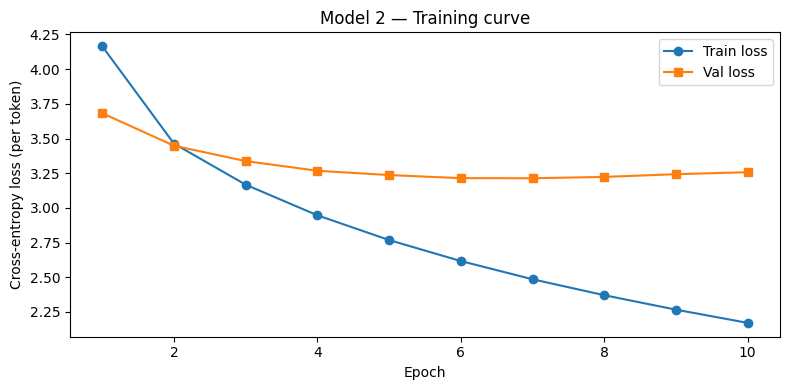

Generating captions on test split (beam_width=3) ...


Generating captions:   0%|          | 0/118 [00:00<?, ?it/s]


  Metric              Model 1        Model 2  Change
  BLEU-1                  nan         0.2108  nan
  BLEU-2                  nan         0.1618  nan
  BLEU-3                  nan         0.1405  nan
  BLEU-4                  nan         0.1284  nan
  ROUGE-L                 nan         0.2426  nan


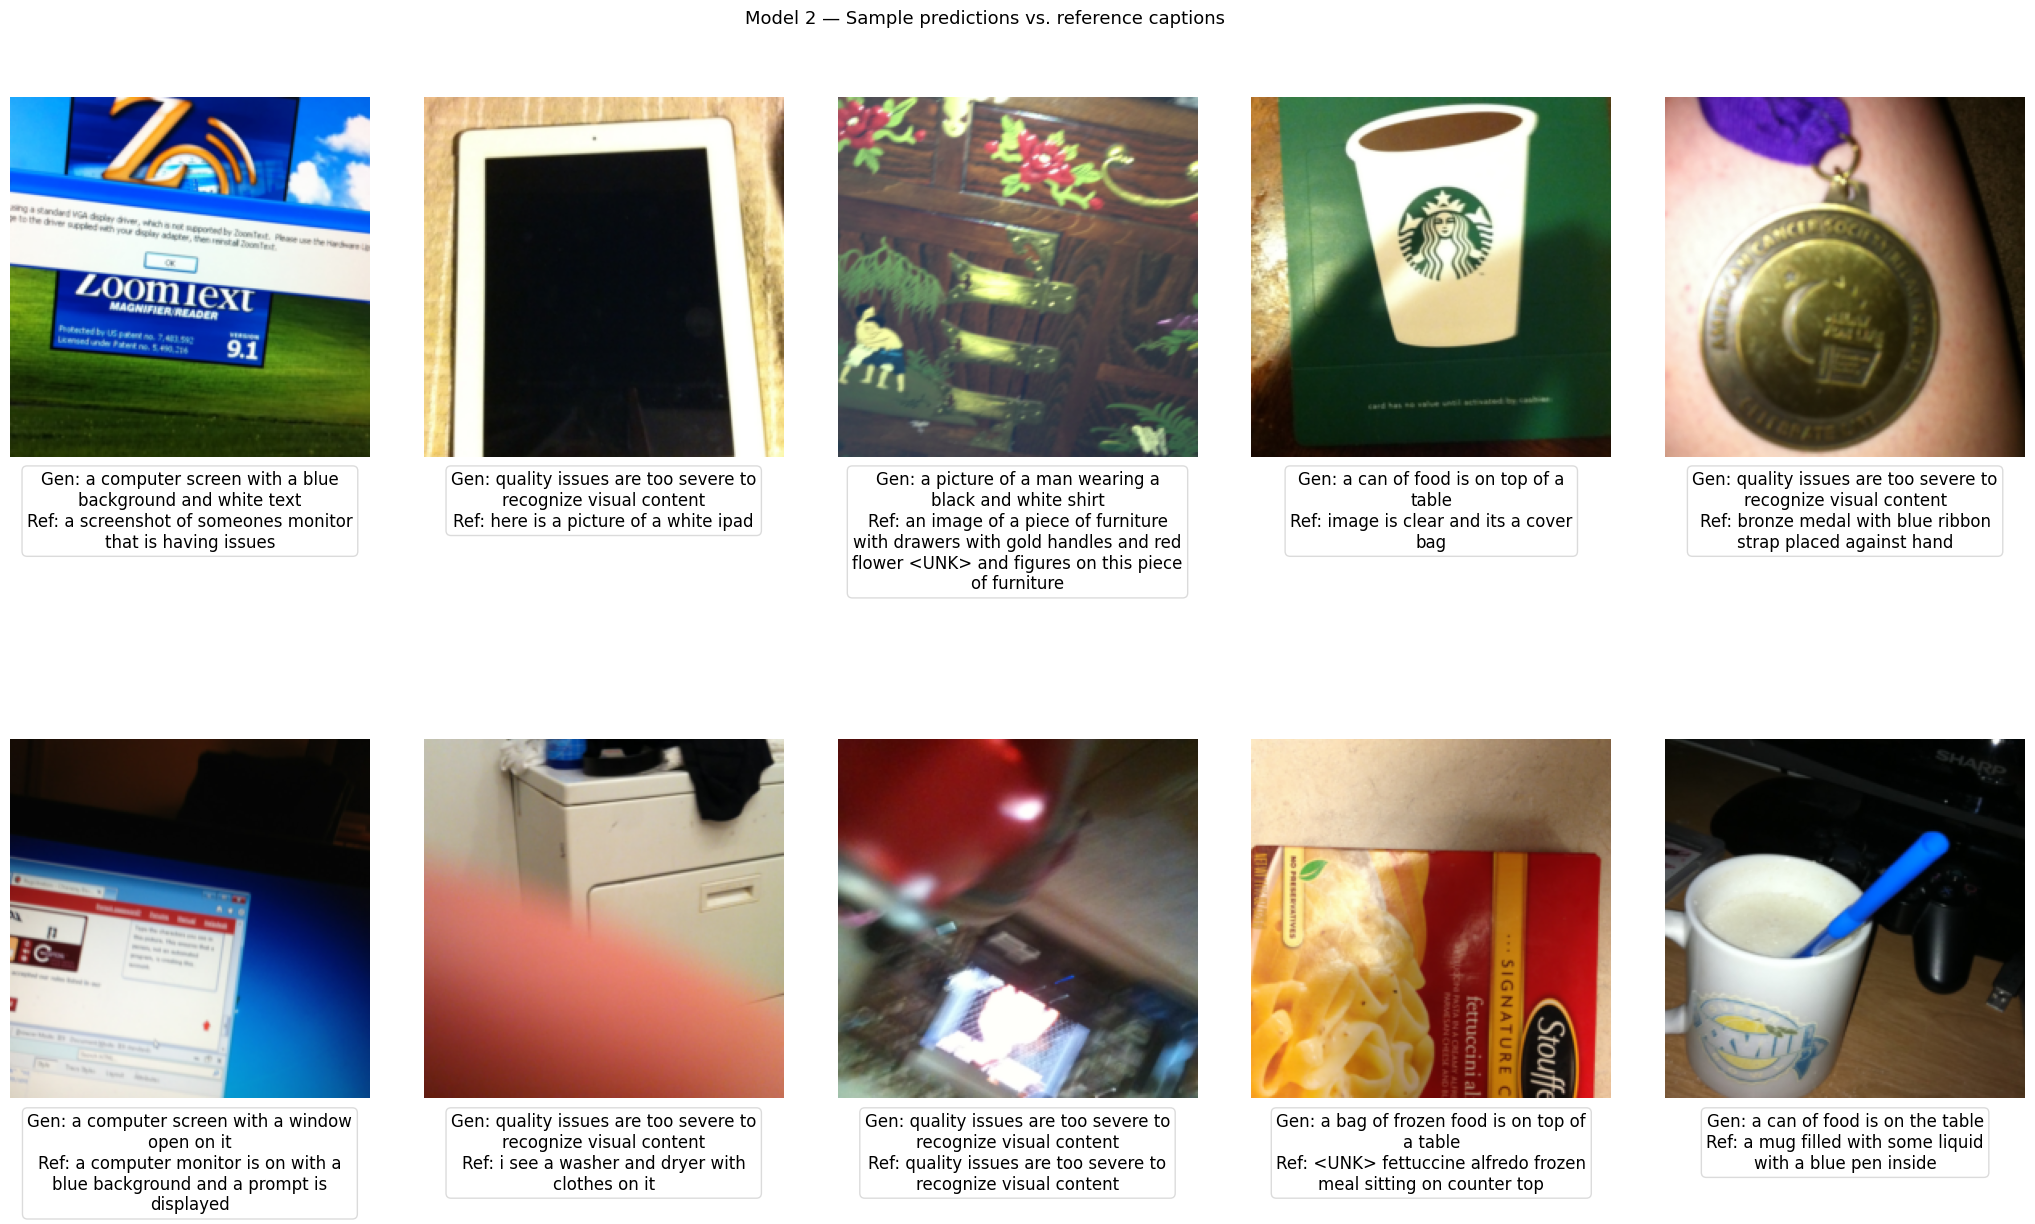

In [75]:
# ── Guard: define evaluation helpers if Model 1 was not run ──────────────────
# These functions are identical to the ones in Model 1. If Model 1 was already
# run they are already in scope and these definitions are simply overwritten
# (no side effects). This makes Model 2 fully self-contained.
import heapq
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm.auto import tqdm
from rouge_score import rouge_scorer
import textwrap

def generate_captions_for_loader(encoder, decoder, loader, device,
                                  beam_width=3, max_len=30):
    encoder.eval()
    decoder.eval()
    hypotheses, references = [], []
    with torch.no_grad():
        for images, captions, lengths in tqdm(loader, desc='Generating captions'):
            images   = images.to(device)
            captions = captions.to(device)
            features = encoder(images)
            for i in range(features.size(0)):
                feat        = features[i].unsqueeze(0)
                pred_tokens = decoder.generate(feat, max_len=max_len, beam_width=beam_width)
                pred_words  = [idx2word.get(t, '<UNK>') for t in pred_tokens]
                hypotheses.append(pred_words)
                ref_tokens = captions[i].tolist()
                ref_words  = []
                for t in ref_tokens:
                    if t in (PAD_IDX, SOS_IDX): continue
                    if t == EOS_IDX: break
                    ref_words.append(idx2word.get(t, '<UNK>'))
                references.append([ref_words])
    return hypotheses, references

def compute_bleu_scores(hypotheses, references):
    smoother = SmoothingFunction().method1
    b1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=smoother)
    b2 = corpus_bleu(references, hypotheses, weights=(.5,.5,0,0), smoothing_function=smoother)
    b3 = corpus_bleu(references, hypotheses, weights=(1/3,1/3,1/3,0), smoothing_function=smoother)
    b4 = corpus_bleu(references, hypotheses, weights=(.25,.25,.25,.25), smoothing_function=smoother)
    return b1, b2, b3, b4

def compute_rouge_l(hypotheses, references):
    scorer_rl = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    total = sum(scorer_rl.score(' '.join(r[0]), ' '.join(h))['rougeL'].fmeasure
                for h, r in zip(hypotheses, references))
    return total / len(hypotheses) if hypotheses else 0.0

def show_predictions(encoder, decoder, dataset, device,
                     n_samples=10, beam_width=3, seed=42):
    encoder.eval(); decoder.eval()
    _mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    _std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    rng     = random.Random(seed)
    indices = rng.sample(range(len(dataset)), n_samples)
    fig, axes = plt.subplots(2, 5, figsize=(26, 12))
    with torch.no_grad():
        for ax, idx in zip(axes.flat, indices):
            image_tensor, caption_tensor = dataset[idx]
            feat        = encoder(image_tensor.unsqueeze(0).to(device))
            pred_tokens = decoder.generate(feat, beam_width=beam_width)
            pred_words  = [idx2word.get(t, '<UNK>') for t in pred_tokens]
            ref_words   = [idx2word.get(t, '<UNK>') for t in caption_tensor.tolist()
                           if t not in (PAD_IDX, SOS_IDX, EOS_IDX)]
            img_show = (image_tensor * _std + _mean).clamp(0,1).permute(1,2,0).numpy()
            ax.imshow(img_show); ax.axis('off')
            gen_w = '\n'.join(textwrap.wrap(f'Gen: {" ".join(pred_words) or "(empty)"}', 38))
            ref_w = '\n'.join(textwrap.wrap(f'Ref: {" ".join(ref_words)  or "(empty)"}', 38))
            ax.text(0.5, -0.04, f'{gen_w}\n{ref_w}', transform=ax.transAxes,
                    fontsize=12, ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              alpha=0.8, edgecolor='lightgray'))
    plt.suptitle('Model 2 — Sample predictions vs. reference captions', fontsize=13)
    plt.subplots_adjust(hspace=0.55, wspace=0.15, bottom=0.05, top=0.93)
    plt.show()

# ── Fallback: Model 1 scores (only needed for the comparison table) ───────────
try:
    _ = b1
except NameError:
    b1 = b2 = b3 = b4 = rouge_l = float('nan')
    print('Model 1 scores not found — comparison table will show NaN for Model 1.')

# ── Reload best checkpoint ────────────────────────────────────────────────────
ckpt2 = torch.load(CKPT_PATH2, map_location=DEVICE)
encoder2.load_state_dict(ckpt2['encoder_state'])
decoder2.load_state_dict(ckpt2['decoder_state'])
print(f'Loaded best checkpoint from epoch {ckpt2["epoch"]}  (val_loss={ckpt2["val_loss"]:.4f})')

# ── Training curve ────────────────────────────────────────────────────────────
epochs_range2 = range(1, len(history2['train_loss']) + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range2, history2['train_loss'], label='Train loss', marker='o')
ax.plot(epochs_range2, history2['val_loss'],   label='Val loss',   marker='s')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss (per token)')
ax.set_title('Model 2 — Training curve')
ax.legend()
plt.tight_layout()
plt.show()

# ── Generate captions — reuse Model 1 function ────────────────────────────────
# generate_captions_for_loader calls decoder.generate(feat) internally.
# For Model 2, feat has shape (1, 49, 512) instead of (1, 512) — compatible.
# ── Generate captions using the cached test features ─────────────────────────
# generate_captions_for_loader calls encoder(images) internally, which would
# be slow. Instead, use the test_cache directly for consistency and speed.
print('Generating captions on test split (beam_width=3) ...')

decoder2.eval()
hyps2, refs2 = [], []
with torch.no_grad():
    for batch_idx, (_, captions, lengths) in enumerate(
            tqdm(test_loader, desc='Generating captions')):
        encoder_out = test_cache[batch_idx].to(DEVICE)   # (B, 49, D)
        captions    = captions.to(DEVICE)
        for i in range(encoder_out.size(0)):
            feat        = encoder_out[i].unsqueeze(0)    # (1, 49, D)
            pred_tokens = decoder2.generate(feat, max_len=30, beam_width=BEAM_WIDTH2)
            pred_words  = [idx2word.get(t, '<UNK>') for t in pred_tokens]
            hyps2.append(pred_words)
            ref_tokens = captions[i].tolist()
            ref_words  = [idx2word.get(t, '<UNK>') for t in ref_tokens
                          if t not in (PAD_IDX, SOS_IDX, EOS_IDX)]
            refs2.append([ref_words])

b1_2, b2_2, b3_2, b4_2 = compute_bleu_scores(hyps2, refs2)
rouge_l2                = compute_rouge_l(hyps2, refs2)

# ── Side-by-side comparison ───────────────────────────────────────────────────
print('\n' + '='*56)
print(f'  {"Metric":<12} {"Model 1":>14} {"Model 2":>14}  Change')
print('='*56)
for name, v1, v2 in [
    ('BLEU-1',  b1,      b1_2),
    ('BLEU-2',  b2,      b2_2),
    ('BLEU-3',  b3,      b3_2),
    ('BLEU-4',  b4,      b4_2),
    ('ROUGE-L', rouge_l, rouge_l2),
]:
    delta = v2 - v1
    sign  = '+' if delta >= 0 else ''
    print(f'  {name:<12} {v1:>14.4f} {v2:>14.4f}  {sign}{delta:.4f}')
print('='*56)

# ── Visual inspection ────────────────────────────────────────────────────────
# Visual inspection — encoder is frozen so pass cached features via a wrapper
# show_predictions calls encoder(image) internally; easier to keep it as-is
# since it samples individual images (not full batches) and speed is not critical.
encoder2.eval()
show_predictions(encoder2, decoder2, test_dataset, DEVICE,
                 n_samples=10, beam_width=BEAM_WIDTH2)